# SEQ - CUDA 

In [11]:
%%writefile types.h
/**
 * @file      types.h
 * @brief     Common type definitions for the entire project.
 * @details   This header defines fundamental data types, structures, and aliases
 *            to promote consistency and portability across the codebase.
 *
 * @copyright  (C) 2025, Manoel Augusto de Souza Serafim
 *             All rights reserved.
 *
 * @author     Manoel Serafim
 * @email      manoel.serafim@proton.me
 * @github     https://github.com/manoel-serafim
*/
#ifndef STD_TYPES_H_
#define STD_TYPES_H_

typedef int int32_t;
typedef unsigned int uint32_t;
typedef double float64_t;

#endif // STD_TYPES_H_

Writing types.h


In [12]:
%%writefile kmeans_1d.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h> //only for timing
#include "types.h"

uint32_t point_amount = 0u;
uint32_t centroid_amount = 0u;
uint32_t iteration_counter = 0u;
uint32_t iteration_limit = 0u;
float64_t sum_squared_errors = 0.0f;
float64_t epsilon = 0.0f;

const float64_t *points = NULL;
float64_t *centroids = NULL;
float64_t *sum_centroid_points = NULL;
uint32_t *amount_centroid_points = NULL;
uint32_t *assignments = NULL;

/* ---------- util CSV 1D: cada linha tem 1 número ---------- */
static uint32_t count_rows(const char *path)
{
    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        exit(1);
    }
    uint32_t rows = 0;
    char line[8192];
    while (fgets(line, sizeof(line), f))
    {
        for (char *p = line; *p; p++)
        {
            if (*p != ' ' && *p != '\t' && *p != '\n' && *p != '\r')
            {
                rows++;
                break;
            }
        }
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path,
                             uint32_t *n_out)
{
    uint32_t R = count_rows(path);
    if (R <= 0)
    {
        fprintf(stderr, "%s: arquivo vazio\n", path);
        exit(1);
    }

    double *A = malloc((unsigned long) R * sizeof(double));
    if (!A)
    {
        perror("malloc");
        exit(1);
    }

    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        free(A);
        exit(1);
    }

    char line[8192];
    uint32_t r = 0;
    while (fgets(line, sizeof(line), f) && r < R)
    {
        char *tok = strtok(line, ",; \t\n\r");
        if (!tok)
        {
            fprintf(stderr, "%s: linha %d sem valor\n", path, r+1);
            free(A);
            fclose(f);
            exit(1);
        }
        A[r++] = atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path,
                             const uint32_t *assign,
                             uint32_t N)
{
    if (!path)
    {
        return;
    }

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t i = 0; i < N; i++)
    {
        fprintf(f, "%d\n", assign[i]);
    }
    fclose(f);
}

static void write_centroids_csv(const char *path,
                                const double *C,
                                uint32_t K)
{
    if (!path)
    {
        return;
    }

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t c = 0; c < K; c++)
    {
        fprintf(f, "%.6f\n", C[c]);
    }
    fclose(f);
}

static void assignment_step_1d(void)
{
    uint32_t point_index = 0u;
    uint32_t centroid_index = 0u;

    uint32_t assign_index = 0u;

    float64_t error = 0.0f;
    float64_t squared_error = 0.0f;
    float64_t squared_error_holder = 0.0f;
    sum_squared_errors = 0.0f;

    point_index = 0u;
    do
    {
        assign_index = 0u;
        error = (points[point_index]-centroids[0]); // compiler would already optimize for reuse under -O2
        squared_error = error * error;

        centroid_index = 1u;
        do
        {

            error = (points[point_index]-centroids[centroid_index]);
            squared_error_holder = error*error;
            if (squared_error > squared_error_holder)
            {
                squared_error = squared_error_holder;
                assign_index = centroid_index;
            }
            ++centroid_index;

        }
        while (centroid_index < centroid_amount);

        assignments[point_index] = assign_index;
        sum_squared_errors += squared_error;
        ++point_index;
    }
    while (point_index < point_amount);

}

static void update_step_1d(void)
{

    memset(sum_centroid_points, 0.0f, centroid_amount*sizeof(float64_t));
    memset(amount_centroid_points, 0u, centroid_amount*sizeof(uint32_t));

    uint32_t point_index = 0u;
    uint32_t centroid_index = 0u;
    do
    {
        centroid_index = assignments[point_index];
        amount_centroid_points[centroid_index]++;
        sum_centroid_points[centroid_index] += points[point_index];
        ++point_index;
    }
    while (point_index < point_amount);

    centroid_index = 0u;
    do
    {
        centroids[centroid_index] = (amount_centroid_points[centroid_index] > 0) ? (sum_centroid_points[centroid_index] / amount_centroid_points[centroid_index]) : points[0];
        ++centroid_index;
    }
    while (centroid_index < centroid_amount);


}

static void kmeans_1d(void)
{
    float64_t sse_holder = 1e300;
    float64_t relative_change = 0.0f;

    sum_centroid_points = calloc((size_t) centroid_amount, sizeof(float64_t));
    amount_centroid_points = calloc((size_t) centroid_amount, sizeof(uint32_t));
    if (!sum_centroid_points || !amount_centroid_points)
    {
        perror("calloc");
        exit(1);
    }

    for (iteration_counter = 0; iteration_counter < iteration_limit; ++iteration_counter)
    {
        assignment_step_1d();
        relative_change = fabs(sum_squared_errors - sse_holder) / (sse_holder > 0.0 ? sse_holder : 1.0);
        if (relative_change < epsilon)
        {
            ++iteration_counter;
            break;
        }
        else
        {
            update_step_1d();
            sse_holder = sum_squared_errors;
        }

    }
    free(sum_centroid_points);
    free(amount_centroid_points);
}

int main(int argc,
         char **argv)
{
    if (argc < 3)
    {
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv]\n", argv[0]);
        printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabeçalho.\n");
        return 1;
    }

    const char *const path_points = argv[1];
    const char *const path_centroids = argv[2];
    iteration_limit = (argc > 3) ? (uint32_t) atoi(argv[3]) : 50u;
    epsilon = (argc > 4) ? atof(argv[4]) : 1e-4;
    const char *path_assignment = (argc > 5) ? argv[5] : NULL;
    const char *path_output_centroid = (argc > 6) ? argv[6] : NULL;

    if (iteration_limit <= 0 || epsilon <= 0.0)
    {
        fprintf(stderr, "max_iter>0 e eps>0\n");
        return 1;
    }


    points = read_csv_1col(path_points, &point_amount);
    centroids = read_csv_1col(path_centroids, &centroid_amount);
    assignments = malloc((size_t) point_amount * sizeof(uint32_t));
    if (!assignments)
    {
        perror("malloc");
        free(centroids);
        free((void *) points);
        return 1;
    }

    double start_time = omp_get_wtime();

    kmeans_1d();

    double end_time = omp_get_wtime();
    double elapsed_ms = (end_time - start_time) * 1000.0;

    printf("K-means 1D (sequential)\n");
    printf("N=%u K=%u max_iter=%u eps=%g threads=1\n",
           point_amount, centroid_amount, iteration_limit, epsilon);
    printf("Iterações: %u | SSE final: %.10f | Tempo: %.6f ms\n",
           iteration_counter, sum_squared_errors, elapsed_ms);

    write_assign_csv(path_assignment, assignments, point_amount);
    write_centroids_csv(path_output_centroid, centroids, centroid_amount);

    free(assignments);
    free(centroids);
    free((void *) points);
    return 0;
}

Overwriting kmeans_1d.c


In [13]:
%%bash
gcc -O3 -Wall kmeans_1d.c -o kmeans_1d_sequential -lm -fopenmp -I.

Runtime → Change runtime type → GPU


# CUDA


In [14]:
%%writefile kmeans_1d.cu

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <cuda_runtime.h>

typedef double float64_t;
typedef unsigned int uint32_t;

uint32_t point_amount = 0u;
uint32_t centroid_amount = 0u;
uint32_t iteration_counter = 0u;
uint32_t iteration_limit = 0u;
float64_t sum_squared_errors = 0.0f;
float64_t epsilon = 0.0f;

const float64_t *points = NULL;
float64_t *centroids = NULL;
uint32_t *assignments = NULL;

float64_t *d_points = NULL;
float64_t *d_centroids = NULL;
uint32_t *d_assignments = NULL;
float64_t *d_sse_array = NULL;
float64_t *d_sum_centroid_points = NULL;
uint32_t *d_amount_centroid_points = NULL;

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error at %s:%d: %s\n", __FILE__, __LINE__, \
                    cudaGetErrorString(err)); \
            exit(EXIT_FAILURE); \
        } \
    } while(0)

static uint32_t count_rows(const char *path)
{
    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        exit(1);
    }
    uint32_t rows = 0;
    char line[8192];
    while (fgets(line, sizeof(line), f))
    {
        for (char *p = line; *p; p++)
        {
            if (*p != ' ' && *p != '\t' && *p != '\n' && *p != '\r')
            {
                rows++;
                break;
            }
        }
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, uint32_t *n_out)
{
    uint32_t R = count_rows(path);
    if (R <= 0)
    {
        fprintf(stderr, "%s: arquivo vazio\n", path);
        exit(1);
    }

    double *A = (double*) malloc((unsigned long) R * sizeof(double));

    if (!A)
    {
        perror("malloc");
        exit(1);
    }

    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        free(A);
        exit(1);
    }

    char line[8192];
    uint32_t r = 0;
    while (fgets(line, sizeof(line), f) && r < R)
    {
        char *tok = strtok(line, ",; \t\n\r");
        if (!tok)
        {
            fprintf(stderr, "%s: linha %d sem valor\n", path, (int) (r+1));
            free(A);
            fclose(f);
            exit(1);
        }
        A[r++] = atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path,
                             const uint32_t *assign,
                             uint32_t N)
{
    if (!path)
        return;

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t i = 0; i < N; i++)
        fprintf(f, "%u\n", assign[i]);
    fclose(f);
}

static void write_centroids_csv(const char *path,
                                const double *C,
                                uint32_t K)
{
    if (!path)
        return;

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t c = 0; c < K; c++)
        fprintf(f, "%.6f\n", C[c]);
    fclose(f);
}

__global__ void assignment_kernel(
    const float64_t *points,
    const float64_t *centroids,
    uint32_t *assignments,
    float64_t *sse_array,
    uint32_t point_amount,
    uint32_t centroid_amount)
{
    uint32_t point_index = blockIdx.x * blockDim.x + threadIdx.x;
    if (point_index >= point_amount)
        return;

    uint32_t best_centroid = 0;
    float64_t error = points[point_index] - centroids[0];
    float64_t min_squared_error = error * error;

    for (uint32_t centroid_index = 1; centroid_index < centroid_amount; ++centroid_index)
    {
        error = points[point_index] - centroids[centroid_index];
        float64_t squared_error = error * error;
        if (squared_error < min_squared_error)
        {
            min_squared_error = squared_error;
            best_centroid = centroid_index;
        }
    }

    assignments[point_index] = best_centroid;
    sse_array[point_index] = min_squared_error;
}

__global__ void update_kernel(
    const float64_t *points,
    const uint32_t *assignments,
    float64_t *sum_centroid_points,
    uint32_t *amount_centroid_points,
    uint32_t point_amount)
{
    uint32_t point_index = blockIdx.x * blockDim.x + threadIdx.x;
    if (point_index >= point_amount)
        return;

    uint32_t centroid_index = assignments[point_index];
    atomicAdd(&sum_centroid_points[centroid_index], points[point_index]);
    atomicAdd(&amount_centroid_points[centroid_index], 1u);
}

__global__ void compute_centroids_kernel(
    float64_t *centroids,
    const float64_t *sum_centroid_points,
    const uint32_t *amount_centroid_points,
    const float64_t *points,
    uint32_t centroid_amount)
{
    uint32_t c = blockIdx.x * blockDim.x + threadIdx.x;
    if (c >= centroid_amount)
        return;

    if (amount_centroid_points[c] > 0)
        centroids[c] = sum_centroid_points[c] / (float64_t)amount_centroid_points[c];
    else
        centroids[c] = points[0];
}

static void assignment_step_1d(int block_size)
{
    int grid_size = (point_amount + block_size - 1) / block_size;

    assignment_kernel<<<grid_size, block_size>>>(
        d_points, d_centroids, d_assignments, d_sse_array,
        point_amount, centroid_amount);

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    float64_t *h_sse_array = (float64_t*)malloc(point_amount * sizeof(float64_t));
    CUDA_CHECK(cudaMemcpy(h_sse_array, d_sse_array,
                          point_amount * sizeof(float64_t), cudaMemcpyDeviceToHost));

    float64_t local_sse = 0.0;
    for (uint32_t i = 0; i < point_amount; ++i)
        local_sse += h_sse_array[i];

    sum_squared_errors = local_sse;
    free(h_sse_array);
}

static void update_step_1d_gpu(int block_size)
{
    int grid_size = (point_amount + block_size - 1) / block_size;

    CUDA_CHECK(cudaMemset(d_sum_centroid_points, 0, centroid_amount * sizeof(float64_t)));
    CUDA_CHECK(cudaMemset(d_amount_centroid_points, 0, centroid_amount * sizeof(uint32_t)));

    update_kernel<<<grid_size, block_size>>>(
        d_points, d_assignments, d_sum_centroid_points,
        d_amount_centroid_points, point_amount);

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    int centroid_grid = (centroid_amount + block_size - 1) / block_size;
    compute_centroids_kernel<<<centroid_grid, block_size>>>(
        d_centroids, d_sum_centroid_points, d_amount_centroid_points,
        d_points, centroid_amount);

    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    CUDA_CHECK(cudaMemcpy(centroids, d_centroids,
                          centroid_amount * sizeof(float64_t), cudaMemcpyDeviceToHost));
}

static void kmeans_1d(int block_size)
{
    float64_t sse_holder = 1e300;
    float64_t relative_change = 0.0f;

    for (iteration_counter = 0; iteration_counter < iteration_limit; ++iteration_counter)
    {
        assignment_step_1d(block_size);

        relative_change = fabs(sum_squared_errors - sse_holder) /
                          (sse_holder > 0.0 ? sse_holder : 1.0);

        if (relative_change < epsilon)
        {
            ++iteration_counter;
            break;
        }
        else
        {
            update_step_1d_gpu(block_size);
            sse_holder = sum_squared_errors;
        }
    }
}

int main(int argc, char **argv)
{
    if (argc < 3)
    {
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv] [block_size=256]\n", argv[0]);
        return 1;
    }

    const char *const path_points = argv[1];
    const char *const path_centroids = argv[2];
    iteration_limit = (argc > 3) ? (uint32_t) atoi(argv[3]) : 50u;
    epsilon = (argc > 4) ? atof(argv[4]) : 1e-4;
    const char *path_assignment = (argc > 5) ? argv[5] : NULL;
    const char *path_output_centroid = (argc > 6) ? argv[6] : NULL;
    int block_size = (argc > 7) ? atoi(argv[7]) : 256;

    points = read_csv_1col(path_points, &point_amount);
    centroids = read_csv_1col(path_centroids, &centroid_amount);
    assignments = (uint32_t*) malloc((size_t) point_amount * sizeof(uint32_t));

    CUDA_CHECK(cudaMalloc(&d_points, point_amount * sizeof(float64_t)));
    CUDA_CHECK(cudaMalloc(&d_centroids, centroid_amount * sizeof(float64_t)));
    CUDA_CHECK(cudaMalloc(&d_assignments, point_amount * sizeof(uint32_t)));
    CUDA_CHECK(cudaMalloc(&d_sse_array, point_amount * sizeof(float64_t)));
    CUDA_CHECK(cudaMalloc(&d_sum_centroid_points, centroid_amount * sizeof(float64_t)));
    CUDA_CHECK(cudaMalloc(&d_amount_centroid_points, centroid_amount * sizeof(uint32_t)));

    cudaEvent_t start_total, stop_total, start_kernel, stop_kernel;
    cudaEvent_t start_h2d, stop_h2d, start_d2h, stop_d2h;
    CUDA_CHECK(cudaEventCreate(&start_total));
    CUDA_CHECK(cudaEventCreate(&stop_total));
    CUDA_CHECK(cudaEventCreate(&start_kernel));
    CUDA_CHECK(cudaEventCreate(&stop_kernel));
    CUDA_CHECK(cudaEventCreate(&start_h2d));
    CUDA_CHECK(cudaEventCreate(&stop_h2d));
    CUDA_CHECK(cudaEventCreate(&start_d2h));
    CUDA_CHECK(cudaEventCreate(&stop_d2h));

    CUDA_CHECK(cudaEventRecord(start_total));

    CUDA_CHECK(cudaEventRecord(start_h2d));
    CUDA_CHECK(cudaMemcpy(d_points, points, point_amount * sizeof(float64_t),
                          cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_centroids, centroids, centroid_amount * sizeof(float64_t),
                          cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaEventRecord(stop_h2d));
    CUDA_CHECK(cudaEventSynchronize(stop_h2d));

    CUDA_CHECK(cudaEventRecord(start_kernel));
    kmeans_1d(block_size);
    CUDA_CHECK(cudaEventRecord(stop_kernel));
    CUDA_CHECK(cudaEventSynchronize(stop_kernel));

    CUDA_CHECK(cudaEventRecord(start_d2h));
    CUDA_CHECK(cudaMemcpy(assignments, d_assignments, point_amount * sizeof(uint32_t),
                          cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(centroids, d_centroids, centroid_amount * sizeof(float64_t),
                          cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaEventRecord(stop_d2h));
    CUDA_CHECK(cudaEventSynchronize(stop_d2h));

    CUDA_CHECK(cudaEventRecord(stop_total));
    CUDA_CHECK(cudaEventSynchronize(stop_total));

    float time_h2d, time_kernel, time_d2h, time_total;
    CUDA_CHECK(cudaEventElapsedTime(&time_h2d, start_h2d, stop_h2d));
    CUDA_CHECK(cudaEventElapsedTime(&time_kernel, start_kernel, stop_kernel));
    CUDA_CHECK(cudaEventElapsedTime(&time_d2h, start_d2h, stop_d2h));
    CUDA_CHECK(cudaEventElapsedTime(&time_total, start_total, stop_total));

    printf("K-means 1D (CUDA - GPU Atomics)\n");
    printf("N=%u K=%u max_iter=%u eps=%g block_size=%d\n",
           point_amount, centroid_amount, iteration_limit, epsilon, block_size);
    printf("Iterações: %u | SSE final: %.10f\n",
           iteration_counter, sum_squared_errors);
    printf("Tempo H2D: %.3f ms | Kernel: %.3f ms | D2H: %.3f ms | Total: %.3f ms\n",
           time_h2d, time_kernel, time_d2h, time_total);

    write_assign_csv(path_assignment, assignments, point_amount);
    write_centroids_csv(path_output_centroid, centroids, centroid_amount);

    CUDA_CHECK(cudaFree(d_points));
    CUDA_CHECK(cudaFree(d_centroids));
    CUDA_CHECK(cudaFree(d_assignments));
    CUDA_CHECK(cudaFree(d_sse_array));
    CUDA_CHECK(cudaFree(d_sum_centroid_points));
    CUDA_CHECK(cudaFree(d_amount_centroid_points));
    CUDA_CHECK(cudaEventDestroy(start_total));
    CUDA_CHECK(cudaEventDestroy(stop_total));
    CUDA_CHECK(cudaEventDestroy(start_kernel));
    CUDA_CHECK(cudaEventDestroy(stop_kernel));
    CUDA_CHECK(cudaEventDestroy(start_h2d));
    CUDA_CHECK(cudaEventDestroy(stop_h2d));
    CUDA_CHECK(cudaEventDestroy(start_d2h));
    CUDA_CHECK(cudaEventDestroy(stop_d2h));

    free(assignments);
    free(centroids);
    free((void *) points);
    return 0;
}


Overwriting kmeans_1d.cu


In [15]:
!nvcc -O3 -arch=sm_75 kmeans_1d.cu -o kmeans_1d

In [16]:
import numpy as np
import os

def write_txt(filename, values):
    np.savetxt(filename, np.array(values, dtype=np.float64), fmt="%.6f")

def make_dataset(name, N, K, stddev, seed, cluster_range_max_multiplier=15):
    np.random.seed(seed)
    base_scales = np.random.exponential(scale=100, size=K)
    signs = np.random.choice([-1, 1], size=K)
    offsets = np.random.uniform(-50, 50, size=K)

    clusters = np.sort(base_scales * signs * cluster_range_max_multiplier + offsets)

    cluster_stddevs = stddev * np.random.uniform(0.5, 2.0, size=K)

    os.makedirs(f"point", exist_ok=True)
    os.makedirs(f"centroid", exist_ok=True)

    points = np.concatenate([
        np.random.normal(mu, sigma, N // K)
        for mu, sigma in zip(clusters, cluster_stddevs)
    ])

    # Embaralhamento
    np.random.shuffle(points)

    write_txt(f"point/{name}.txt", points)
    write_txt(f"centroid/{name}.txt", clusters)

    print(f"Generated {name:<7}: N={N:>7} K={K:<2} σ={stddev:<4} → points/{name}.txt")
    print(f"  Cluster range: [{clusters.min():.2f}, {clusters.max():.2f}], magnitude span: {clusters.max() - clusters.min():.2f}")

make_dataset(name="small",  N=10_000,  K=4,  stddev=0.8, seed=42)
make_dataset(name="medium", N=100_000, K=8,  stddev=1.0, seed=123)
make_dataset(name="large",  N=1_000_000, K=16, stddev=1.5, seed=999)

Generated small  : N=  10000 K=4  σ=0.8  → points/small.txt
  Cluster range: [-1965.01, 4551.80], magnitude span: 6516.81
Generated medium : N= 100000 K=8  σ=1.0  → points/medium.txt
  Cluster range: [-1938.36, 5929.63], magnitude span: 7867.99
Generated large  : N=1000000 K=16 σ=1.5  → points/large.txt
  Cluster range: [-2375.82, 2418.25], magnitude span: 4794.07


In [4]:
import subprocess
import re

def run_kmeans_and_parse_output(points_file_path, centroids_file_path, block_size):
    """
    Executes the kmeans_1d program and parses its output to extract performance metrics.

    Args:
        points_file_path (str): Path to the input points data file.
        centroids_file_path (str): Path to the initial centroids data file.
        block_size (int): The block size to be used by the CUDA kernel.

    Returns:
        dict: A dictionary containing the extracted metrics, or None if parsing fails.
    """
    command = [
        "./kmeans_1d",
        points_file_path,
        centroids_file_path,
        "50",  # max_iter
        "1e-4",  # eps
        "assign.csv",  # path_assignment
        "centroids.csv",  # path_output_centroid
        str(block_size), # block_size
        "1" # use_gpu_update
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output = result.stdout

        metrics = {}

        # Regex patterns to extract data
        n_k_block_pattern = r"N=(?P<N>\d+) K=(?P<K>\d+) max_iter=\d+ eps=[\d.eE+-]+ block_size=(?P<block_size>\d+)"
        iteration_sse_pattern = r"Iterações: (?P<iterations>\d+) \| SSE final: (?P<sse_final>[\d.]+)"
        time_pattern = r"Tempo H2D: (?P<h2d>[\d.]+) ms \| Kernel: (?P<kernel>[\d.]+) ms \| D2H: (?P<d2h>[\d.]+) ms \| Total: (?P<total>[\d.]+) ms"

        # Extract N, K, block_size
        match_n_k_block = re.search(n_k_block_pattern, output)
        if match_n_k_block:
            metrics['N'] = int(match_n_k_block.group('N'))
            metrics['K'] = int(match_n_k_block.group('K'))
            metrics['block_size'] = int(match_n_k_block.group('block_size'))

        # Extract iterations and SSE final
        match_iter_sse = re.search(iteration_sse_pattern, output)
        if match_iter_sse:
            metrics['iterations'] = int(match_iter_sse.group('iterations'))
            metrics['SSE final'] = float(match_iter_sse.group('sse_final'))

        # Extract times
        match_time = re.search(time_pattern, output)
        if match_time:
            metrics['Tempo H2D'] = float(match_time.group('h2d'))
            metrics['Kernel'] = float(match_time.group('kernel'))
            metrics['D2H'] = float(match_time.group('d2h'))
            metrics['Total'] = float(match_time.group('total'))

        return metrics

    except subprocess.CalledProcessError as e:
        print(f"Error executing kmeans_1d: {e.stderr}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

print("Function `run_kmeans_and_parse_output` defined successfully.")

Function `run_kmeans_and_parse_output` defined successfully.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

def plot_performance_metric(df, metric, title_prefix, ylabel):
    plt.figure(figsize=(10, 6))
    # Group by 'N' (dataset size) to plot separate lines for each dataset
    for name, group in df.groupby('N'):
        plt.plot(group['block_size'], group[metric], marker='o', label=f'N={name}')

    plt.title(f'{title_prefix} by Block Size for Different Datasets')
    plt.xlabel('Block Size')
    plt.ylabel(ylabel)
    plt.xticks(df['block_size'].unique()) # Ensure all block sizes are shown as ticks
    plt.legend(title='Dataset Size (N)')
    plt.grid(True)
    plt.show()

print("Plotting functions defined.")

Plotting functions defined.


In [6]:
import pandas as pd

dataset_names = ["small", "medium", "large"]
block_sizes = [64, 128, 256, 512, 1024]

all_metrics = []

for dataset_name in dataset_names:
    points_file = f"point/{dataset_name}.txt"
    centroids_file = f"centroid/{dataset_name}.txt"

    print(f"\nRunning tests for dataset: {dataset_name}")
    for bs in block_sizes:
        print(f"  Testing with block size: {bs}...")
        metrics = run_kmeans_and_parse_output(points_file, centroids_file, bs)
        if metrics:
            all_metrics.append(metrics)
        else:
            print(f"    Failed to get metrics for {dataset_name} with block size {bs}")

performance_df = pd.DataFrame(all_metrics)
print("\nPerformance Metrics Table:")
print(performance_df.to_markdown(index=False))



Running tests for dataset: small
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Running tests for dataset: medium
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Running tests for dataset: large
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Performance Metrics Table:
|          N |   K |   block_size |   iterations |        SSE final |   Tempo H2D |   Kernel |   D2H |   Total |
|-----------:|----:|-------------:|-------------:|-----------------:|------------:|---------:|------:|--------:|
|  10000     |   4 |           64 |            3 |  12827.3         |       1.286 |    0.536 | 0.042 |   1.89  |
|  10000     |   4 |

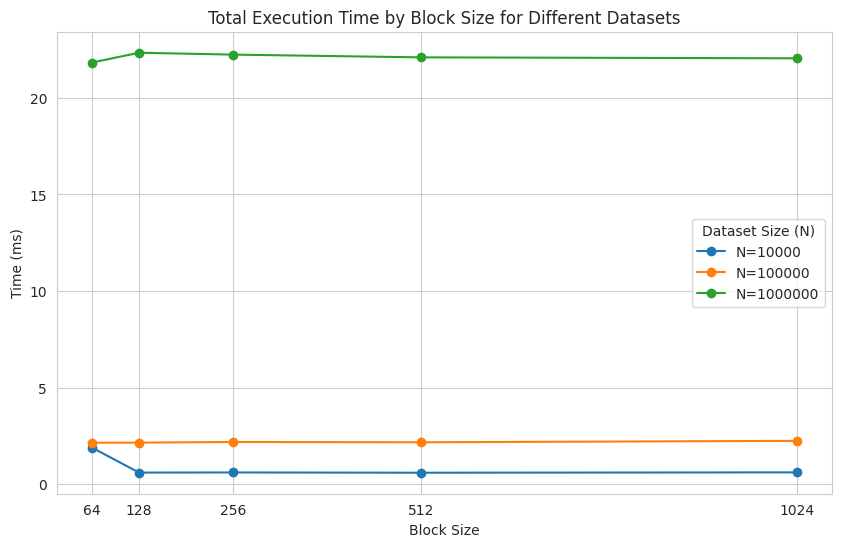

In [7]:
plot_performance_metric(performance_df, 'Total', 'Total Execution Time', 'Time (ms)')

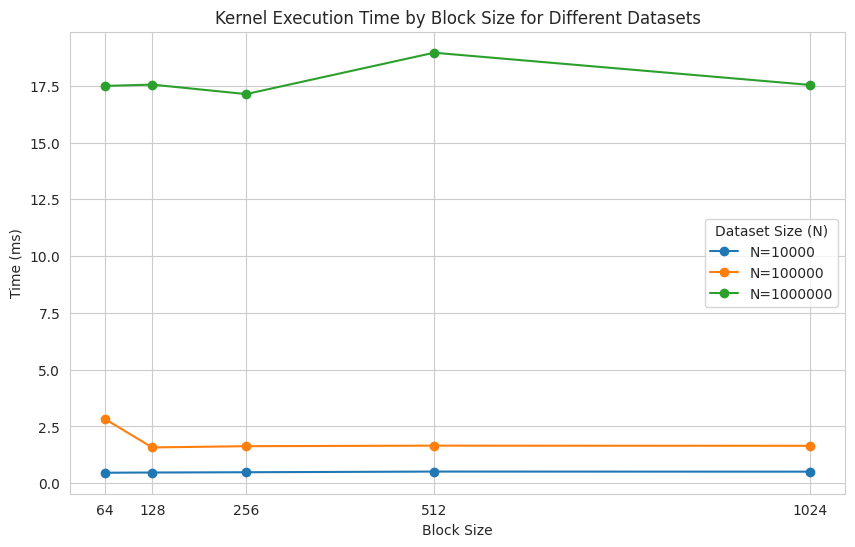

In [14]:
# Plot Kernel execution time
plot_performance_metric(performance_df, 'Kernel', 'Kernel Execution Time', 'Time (ms)')

In [17]:
import subprocess
import re
import numpy as np

def run_kmeans_cuda_and_parse_output(points_file_path, centroids_file_path, block_size, num_runs=20):
    """
    Executes the kmeans_1d CUDA program multiple times and parses its output to extract averaged performance metrics.

    Args:
        points_file_path (str): Path to the input points data file.
        centroids_file_path (str): Path to the initial centroids data file.
        block_size (int): The block size to be used by the CUDA kernel.
        num_runs (int): The number of times to run the CUDA program for averaging.

    Returns:
        dict: A dictionary containing the extracted metrics, or None if parsing fails.
    """
    all_h2d_times = []
    all_kernel_times = []
    all_d2h_times = []
    all_total_times = []

    first_run_metrics = {}

    for i in range(num_runs):
        command = [
            "./kmeans_1d",
            points_file_path,
            centroids_file_path,
            "50",  # max_iter
            "1e-7",  # eps
            "assign.csv",  # path_assignment
            "centroids.csv",  # path_output_centroid
            str(block_size) # block_size
        ]

        try:
            result = subprocess.run(command, capture_output=True, text=True, check=True)
            output = result.stdout

            # Regex patterns to extract data
            n_k_block_pattern = r"N=(?P<N>\d+) K=(?P<K>\d+) max_iter=\d+ eps=[\d.eE+-]+ block_size=(?P<block_size>\d+)"
            iteration_sse_pattern = r"Iterações: (?P<iterations>\d+) \| SSE final: (?P<sse_final>[\d.]+)"
            time_pattern = r"Tempo H2D: (?P<h2d>[\d.]+) ms \| Kernel: (?P<kernel>[\d.]+) ms \| D2H: (?P<d2h>[\d.]+) ms \| Total: (?P<total>[\d.]+) ms"

            # Extract N, K, block_size, iterations, SSE final from the first run
            if not first_run_metrics:
                match_n_k_block = re.search(n_k_block_pattern, output)
                if match_n_k_block:
                    first_run_metrics['N'] = int(match_n_k_block.group('N'))
                    first_run_metrics['K'] = int(match_n_k_block.group('K'))
                    first_run_metrics['block_size'] = int(match_n_k_block.group('block_size'))

                match_iter_sse = re.search(iteration_sse_pattern, output)
                if match_iter_sse:
                    first_run_metrics['iterations'] = int(match_iter_sse.group('iterations'))
                    first_run_metrics['SSE final'] = float(match_iter_sse.group('sse_final'))

            # Extract times for each run
            match_time = re.search(time_pattern, output)
            if match_time:
                all_h2d_times.append(float(match_time.group('h2d')))
                all_kernel_times.append(float(match_time.group('kernel')))
                all_d2h_times.append(float(match_time.group('d2h')))
                all_total_times.append(float(match_time.group('total')))
            else:
                print(f"    Warning: Could not parse time metrics for run {i+1} of CUDA program.")

        except subprocess.CalledProcessError as e:
            print(f"Error executing kmeans_1d CUDA (run {i+1}): {e.stderr}")
            return None
        except Exception as e:
            print(f"An unexpected error occurred during CUDA run {i+1}: {e}")
            return None

    if not all_total_times:
        print(f"No successful CUDA runs for N={first_run_metrics.get('N')} K={first_run_metrics.get('K')} block_size={block_size}.")
        return None

    # Calculate averages
    avg_metrics = {
        'Tempo H2D': np.mean(all_h2d_times),
        'Kernel': np.mean(all_kernel_times),
        'D2H': np.mean(all_d2h_times),
        'Total': np.mean(all_total_times)
    }

    # Combine constant metrics from the first run with averaged times
    final_metrics = {**first_run_metrics, **avg_metrics}
    return final_metrics

def run_kmeans_sequential_and_parse_output(points_file_path, centroids_file_path):
    """
    Executes the sequential kmeans_1d program and parses its output to extract performance metrics.

    Args:
        points_file_path (str): Path to the input points data file.
        centroids_file_path (str): Path to the initial centroids data file.

    Returns:
        dict: A dictionary containing the extracted metrics, or None if parsing fails.
    """
    command = [
        "./kmeans_1d_sequential",
        points_file_path,
        centroids_file_path,
        "50",  # max_iter
        "1e-7",  # eps
        "assign_seq.csv",  # path_assignment
        "centroids_seq.csv"  # path_output_centroid
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output = result.stdout

        metrics = {}

        # Regex patterns to extract data
        n_k_pattern = r"N=(?P<N>\d+) K=(?P<K>\d+) max_iter=\d+ eps=[\d.eE+-]+ threads=1"
        iteration_sse_time_pattern = r"Iterações: (?P<iterations>\d+) \| SSE final: (?P<sse_final>[\d.]+) \| Tempo: (?P<tempo>[\d.]+) ms"

        # Extract N, K
        match_n_k = re.search(n_k_pattern, output)
        if match_n_k:
            metrics['N'] = int(match_n_k.group('N'))
            metrics['K'] = int(match_n_k.group('K'))

        # Extract iterations, SSE final, and Tempo
        match_iter_sse_time = re.search(iteration_sse_time_pattern, output)
        if match_iter_sse_time:
            metrics['iterations'] = int(match_iter_sse_time.group('iterations'))
            metrics['SSE final'] = float(match_iter_sse_time.group('sse_final'))
            metrics['Tempo Sequential'] = float(match_iter_sse_time.group('tempo'))

        return metrics

    except subprocess.CalledProcessError as e:
        print(f"Error executing kmeans_1d_sequential: {e.stderr}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred with sequential run: {e}")
        return None

print("Functions `run_kmeans_cuda_and_parse_output` and `run_kmeans_sequential_and_parse_output` defined successfully.")

Functions `run_kmeans_cuda_and_parse_output` and `run_kmeans_sequential_and_parse_output` defined successfully.


In [18]:
import pandas as pd

dataset_names = ["small", "medium", "large"]
block_sizes = [64, 128, 256, 512, 1024]

all_metrics = []
sequential_baselines = {}

# --- Step 1: Establish Sequential Baselines ---
for dataset_name in dataset_names:
    points_file = f"point/{dataset_name}.txt"
    centroids_file = f"centroid/{dataset_name}.txt"

    print(f"\nEstablishing sequential baseline for dataset: {dataset_name}")
    seq_metrics = run_kmeans_sequential_and_parse_output(points_file, centroids_file)
    if seq_metrics:
        sequential_baselines[dataset_name] = seq_metrics['Tempo Sequential']
        print(f"  Sequential Time for {dataset_name}: {seq_metrics['Tempo Sequential']:.3f} ms")
    else:
        print(f"  Failed to get sequential metrics for {dataset_name}")
        sequential_baselines[dataset_name] = np.nan # Mark as NaN if sequential run failed

# --- Step 2: Run Averaged CUDA Tests ---
for dataset_name in dataset_names:
    points_file = f"point/{dataset_name}.txt"
    centroids_file = f"centroid/{dataset_name}.txt"
    seq_time = sequential_baselines.get(dataset_name, np.nan)

    print(f"\nRunning CUDA tests for dataset: {dataset_name}")
    for bs in block_sizes:
        print(f"  Testing with block size: {bs}...")
        cuda_metrics = run_kmeans_cuda_and_parse_output(points_file, centroids_file, bs)
        if cuda_metrics:
            cuda_metrics['Sequential_Time'] = seq_time
            all_metrics.append(cuda_metrics)
        else:
            print(f"    Failed to get CUDA metrics for {dataset_name} with block size {bs}")

performance_df = pd.DataFrame(all_metrics)

# --- Step 3: Calculate Speedup ---
# Only calculate speedup if 'Sequential_Time' is valid (not NaN or zero)
performance_df['Speedup'] = performance_df.apply(
    lambda row: row['Sequential_Time'] / row['Total'] if row['Total'] > 0 and not pd.isna(row['Sequential_Time']) else np.nan,
    axis=1
)

print("\nPerformance Metrics Table with Speedup:")
print(performance_df.to_markdown(index=False))



Establishing sequential baseline for dataset: small
  Sequential Time for small: 0.190 ms

Establishing sequential baseline for dataset: medium
  Sequential Time for medium: 3.012 ms

Establishing sequential baseline for dataset: large
  Sequential Time for large: 54.808 ms

Running CUDA tests for dataset: small
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Running CUDA tests for dataset: medium
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Running CUDA tests for dataset: large
  Testing with block size: 64...
  Testing with block size: 128...
  Testing with block size: 256...
  Testing with block size: 512...
  Testing with block size: 1024...

Performance Metrics Table with Speedup:
|          N |   K |   block_size |   iterations |     

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

def plot_performance_metric(df, metric, title_prefix, ylabel):
    plt.figure(figsize=(10, 6))
    # Group by 'N' (dataset size) to plot separate lines for each dataset
    for name, group in df.groupby('N'):
        plt.plot(group['block_size'], group[metric], marker='o', label=f'N={name}')

    plt.title(f'{title_prefix} by Block Size for Different Datasets')
    plt.xlabel('Block Size')
    plt.ylabel(ylabel)
    plt.xticks(df['block_size'].unique()) # Ensure all block sizes are shown as ticks
    plt.legend(title='Dataset Size (N)')
    plt.grid(True)
    plt.show()

def plot_speedup(df):
    plt.figure(figsize=(10, 6))
    for name, group in df.groupby('N'):
        plt.plot(group['block_size'], group['Speedup'], marker='o', label=f'N={name}')

    plt.title('Speedup (CUDA vs. Sequential) by Block Size for Different Datasets')
    plt.xlabel('Block Size')
    plt.ylabel('Speedup (Sequential Time / CUDA Total Time)')
    plt.xticks(df['block_size'].unique())
    plt.axhline(y=1, color='r', linestyle='--', label='No Speedup (Speedup = 1)')
    plt.legend(title='Dataset Size (N)')
    plt.grid(True)
    plt.show()

print("Plotting functions defined, including speedup visualization.")

Plotting functions defined, including speedup visualization.


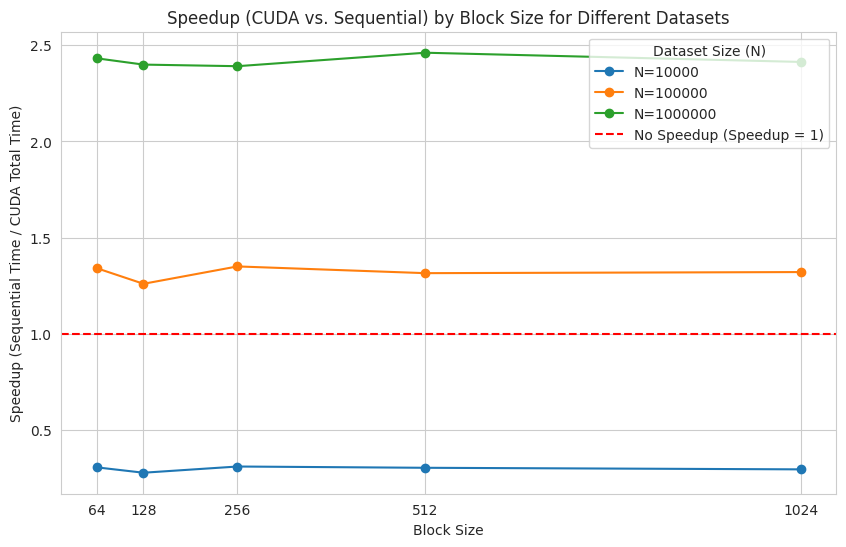

In [20]:
plot_speedup(performance_df)